In [1]:
import pymupdf

doc = pymupdf.open(
    r"/Users/mikifoster/Documents/Code_Projects/rags_to_agents/agent_experimental_builds/input_docs/books/math-engineers.pdf"
)

In [2]:
len(doc)

442

In [3]:
doc[100]

page 100 of </Users/mikifoster/Documents/Code_Projects/rags_to_agents/agent_experimental_builds/input_docs/books/math-engineers.pdf, doc# 1>

In [6]:
print(doc[100].get_text())

ADDITIONAL  RULES  OF  DIFFERENTIATION        83 
If  z  is  a  function  of  x  and  y,  i.  e.,  z  —  f(x,  y),  the  total  differential 
dz  is  obtained  from  the  partial  differentials  dx  and  dy  by  the  use 
of  the  following  rule — 
fdz 
dy 
dy. 
The  reason  for  this  is  more  clearly  seen  if  we  work  from  the 
fundamental  idea  of  rates  of  change,  and  introduce  the  actually 
measurable  quantities  like  Sz,  Sx  and  Sy. 
FIG.  21. 
Thus — 
or  total  change  in  z  =  change  in  z  due  to  the  change  in 
change  in  z  due  to  the  change  in  y. 
The  change  in  z  due  to  the  change  in  x  must  be  measured  by 
the  product  of  the  change  in  x  multiplied  by  the  rate  at  which  z 
is  changing  with  regard  to  x ;  and  this  fact  can  be  better  illustrated 
by  reference  to  a  diagram  (Fig.  21). 
Let  P  be  a  point  (x,  y,  z)  on  a  surface,  and  let  P  move  to  a  new 
position  Q  near  to  P.  The  change  of

In [7]:
matrix = pymupdf.Matrix(1.5, 1.5)
pixmap = doc[100].get_pixmap(matrix=matrix)
png_bytes = pixmap.tobytes(output="png")

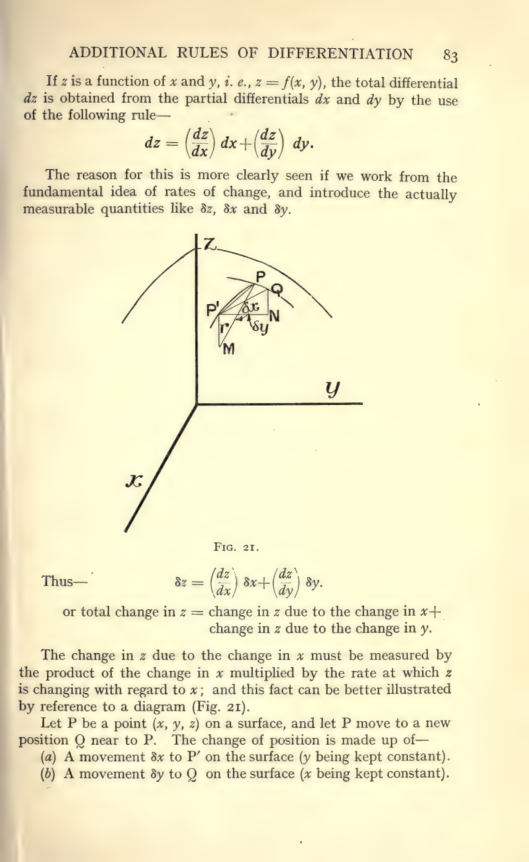

In [8]:
from PIL import Image
import io

img = Image.open(io.BytesIO(png_bytes))
img

In [9]:
import base64

b64 = base64.b64encode(png_bytes).decode("utf-8")
image_url = f"data:image/png;base64,{b64}"

In [10]:
from openai import OpenAI

openai_client = OpenAI()

instructions = """
extract text from this image verbatim

for equations, use latex, $ for inline, and $$ for blocks
""".strip()

messages = [
    {"role": "system", "content": instructions},
    {
        "role": "user",
        "content": [
            {
                "type": "input_image",
                "image_url": image_url,
            },
        ],
    },
]

response = openai_client.responses.create(
    model="gpt-4o-mini",
    input=messages,
)

In [11]:
print(response.output_text)

```
ADDITIONAL RULES OF DIFFERENTIATION 83

If $z$ is a function of $x$ and $y$, i. e., $z = f(x, y)$, the total differential $dz$ is obtained from the partial differentials $dx$ and $dy$ by the use of the following rule

$$
dz = \left( \frac{dz}{dx} \right) dx + \left( \frac{dz}{dy} \right) dy.
$$

The reason for this is more clearly seen if we work from the fundamental idea of rates of change, and introduce the actually measurable quantities like $dz$, $dx$ and $dy$.

\begin{center}
\begin{tikzpicture}[line cap=round,line join=round]
\draw[->] (-1,0) -- (5,0);
\draw[->] (0,-1) -- (0,5);
\draw[->] (0,0) -- (3,3);
\foreach \i in {1, 2, ..., 3} {
  \foreach \j in {1, 2, ..., 3} {
    \draw[fill=black] (1.5,1.5) circle (2pt);
  }
}
\node at (3.5,0.2) {$x$};
\node at (0.2,3.5) {$y$};
\node at (0.5,0.5) {$z$};
\node at (2,-0.5) {P};
\node at (3.5,2) {Q};
\node at (1,-1) {P'};
\node at (3.5,1.5) {N};
\node at (1.5,3.5) {M};
\end{tikzpicture}
\end{center}

Thus—

$$
dz = \left( \frac{dz}{dx}

In [12]:
MODEL_PRICES = {
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    "gpt-5-nano": {"input": 0.075, "output": 0.30},
    "gpt-5-mini": {"input": 0.25, "output": 2.00},
    "gpt-5.2": {"input": 1.75, "output": 14.00},
    "gpt-5.2-pro": {"input": 21.00, "output": 168.00},
}


def calculate_cost(model_name: str, input_tokens: int, output_tokens: int) -> float:
    prices = MODEL_PRICES[model_name.lower()]
    input_cost = (input_tokens / 1_000_000) * prices["input"]
    output_cost = (output_tokens / 1_000_000) * prices["output"]
    return input_cost + output_cost

In [13]:
calculate_cost(
    model_name="gpt-4o-mini",
    input_tokens=response.usage.input_tokens,
    output_tokens=response.usage.output_tokens,
)

0.00421185

In [14]:
instructions = """
extract text from this image verbatim

for equations, use latex, $ for inline, and $$ for blocks

important: don't skip any text. if something is not possible to
recognize, include a placeholder
""".strip()

messages = [
    {"role": "system", "content": instructions},
    {
        "role": "user",
        "content": [
            {"type": "input_image", "image_url": image_url, "detail": "low"},
        ],
    },
]

response = openai_client.responses.create(
    model="gpt-4o-mini",
    input=messages,
)

print(response.output_text)

Here is the extracted text from the image:

```
ADDITIONAL RULES OF DIFFERENTIATION 83

If $z$ is a function of $x$ and $y$, i.e., $z = f(x, y)$, the total differential $dz$ is obtained from the partial differentials $dx$ and $dy$ by the use of the following formula:

$$
dz = \frac{\partial z}{\partial x} dx + \frac{\partial z}{\partial y} dy
$$

The reason for this is more clearly seen if we work from the fundamental idea of change, and introduce the actually measurable quantities like $x$, $y$, and $z$.

Thus—

$$
\text{or total change in } z = \text{change in } z \text{ due to the change in } x + \text{change in } z \text{ due to the change in } y.
$$

The change in $z$ due to a change in $x$ may be measured by the product of the change in $x$ multiplied by the rate at which $z$ is varying with respect to $x$; and that fact can be better illustrated by referring to a diagram (Fig. 21).

Let $P$ be a point $(x, y)$ on a surface, and let $P$ move to a new position $Q$ near to $P$. The

In [15]:
calculate_cost(
    model_name="gpt-4o-mini",
    input_tokens=response.usage.input_tokens,
    output_tokens=response.usage.output_tokens,
)

0.0006245999999999999

In [ ]:
from page_extract import Page
Page.model_json_schema()

{'$defs': {'EquationBlock': {'description': 'A mathematical expression written in LaTeX.',
   'properties': {'type': {'const': 'equation',
     'default': 'equation',
     'title': 'Type',
     'type': 'string'},
    'latex': {'description': 'The equation in LaTeX format.',
     'title': 'Latex',
     'type': 'string'},
    'description': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default': None,
     'description': 'Optional plain-language meaning or interpretation of the equation.',
     'title': 'Description'}},
   'required': ['latex'],
   'title': 'EquationBlock',
   'type': 'object'},
  'FigureBlock': {'properties': {'type': {'const': 'figure',
     'default': 'figure',
     'title': 'Type',
     'type': 'string'},
    'caption': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default': None,
     'description': 'Figure caption or label, if present.',
     'title': 'Caption'},
    'description': {'description': 'Conceptual description of what the figure shows

In [38]:
instructions = """
You are extracting a textbook page into structured page blocks.

text and formulas should be extracted verbatim.

use latex for all math.
Use "$" for inline equation and EquationBlock type for block equations.

some inline equations should be treated as block equations
if there's little text around them.

important: don't skip any text. if something is not possible to
recognize, include a placeholder

Extraction rules:
1) Preserve reading order. The blocks list must match the order a human reads the page.
2) Do NOT include OCR or layout details (no coordinates, fonts, line breaks, or scan artifacts).
3) Prefer fewer, larger TextBlocks over many tiny ones. Group adjacent paragraphs when they belong together.
4) Use LaTeX for all math in EquationBlock.latex.
5) Section headings must be SectionHeadingBlock only; do not include body text in them.
6) FigureBlock.description should explain what the figure conveys conceptually (graphs, curves, relationships),
   not how it looks on the page.
7) TableBlock should capture semantic columns and rows. Include units in column names if shown.
8) Store the running page header (if any) in Page.header.
9) If uncertain, make a best-faith concise extraction; do not invent content.
""".strip()

messages = [
    {"role": "system", "content": instructions},
    {
        "role": "user",
        "content": [
            {"type": "input_image", "image_url": image_url, "detail": "low"},
        ],
    },
]


response = openai_client.responses.parse(
    model="gpt-4o-mini", input=messages, text_format=Page
)

cost = calculate_cost(
    model_name="gpt-4o-mini",
    input_tokens=response.usage.input_tokens,
    output_tokens=response.usage.output_tokens,
)

print("cost=", cost)

cost= 0.00079545


In [35]:
import importlib
import page_extract

importlib.reload(page_extract)

Page = page_extract.Page

In [39]:
page = response.output_parsed
page.print()

83
ADDITIONAL RULES OF DIFFERENTIATION
If z is a function of x and y, i.e., z = f(x, y), the total differential dz is obtained from the partial differentials dx and dy by the use of the following formula: 

$$dz = \frac{\partial z}{\partial x} dx + \frac{\partial z}{\partial y} dy$$

The reason for this is more clearly seen if we follow from the fundamental idea of a function and, introduce the actually measurable quantities like z, x, and y.

None
The figure illustrates the relationship between the variables x, y, and z, showing how a change in x and y affects the total change in z. It visually represents a point moving on the surface defined by the function z = f(x, y).
Fig. 1

Thus: 

\[ \text{total change in } z = \text{change in } z \text{ due to the change in } x. \] 

The change in z due to x can be measured by the product of the change in x multiplied by the rate at which z responds to a change in x; and that fact can be better illustrated by referring to a diagram (Fig. 21).



In [40]:
model_name = "gpt-5-mini"
# model_name = "gpt-4o-mini"

response = openai_client.responses.parse(
    model=model_name, input=messages, text_format=Page
)

cost = calculate_cost(
    model_name=model_name,
    input_tokens=response.usage.input_tokens,
    output_tokens=response.usage.output_tokens,
)

print("cost=", cost)

cost= 0.006881


In [41]:
page = response.output_parsed
page.print()

83
ADDITIONAL RULES OF DIFFERENTIATION
type='section_heading' title='ADDITIONAL RULES OF DIFFERENTIATION'

If $z$ is a function of $x$ and $y$, i. e., $z = f(x, y)$, the total differential $dz$ is obtained from the partial differentials $dx$ and $dy$ by the use of the following rule—

$$dz = \left(\frac{dz}{dx}\right) dx + \left(\frac{dz}{dy}\right) dy$$

The reason for this is more clearly seen if we work from the fundamental idea of rates of change, and introduce the actually measurable quantities like $\delta z$, $\delta x$ and $\delta y$.

Fig. 21.
Conceptual diagram of a surface $z=f(x,y)$ with axes labeled $x,y,z$. A point $P$ at $(x,y,z)$ moves to nearby positions (shown as $P'$, $Q$, etc.); the small changes $\delta x$ and $\delta y$ produce a corresponding change $\delta z$. The figure illustrates decomposing the overall displacement into a movement keeping $y$ constant (showing effect of $\delta x$) and a movement keeping $x$ constant (showing effect of $\delta y$), and how t

In [1]:
import requests

url = "https://github.com/alexeygrigorev/ai-engineering-buildcamp-code/releases/download/math-book-pages/math-book-pages.tar.gz"

tag_gz_content = requests.get(url).content

In [2]:
tag_gz_content[:10]

b'\x1f\x8b\x08\x00\x00\x00\x00\x00\x00\x03'

In [3]:
import tarfile
import io

archive = tarfile.open(fileobj=io.BytesIO(tag_gz_content), mode="r:gz")

In [4]:
for file_info in archive.getmembers():
    filename = file_info.name

    if not filename.endswith(".json"):
        continue

    break

In [5]:
file = archive.extractfile(filename)
content = file.read()

In [7]:
import json

filename = "output/page_092.json"
file = archive.extractfile(filename)
content = file.read()
book_page = json.loads(content)

In [8]:
from page_extract import PageResponse

# validate dictionary
page_response = PageResponse.model_validate(book_page)
page_response

PageResponse(page=Page(page_number=75, header='ADDITIONAL RULES OF DIFFERENTIATION', blocks=[TextBlock(type='text', text='Example 12—If $ y = g(t) = 4x + 4x^{2} \\cdot 1929  \\cdot 2 + \\ldots \n\nLet $ u = \\frac{ du}{dx} = 4 + 8x $.'), EquationBlock(type='equation', latex='\\frac{dy}{dx} = \\frac{dy}{du} \\cdot \\frac{du}{dx} = 4 \\cdot (4 + 8x) = \\ldots \n\nHence:\n\n$ \\frac{dy}{dx} = (4 \\cdot 1928 + 8x \\cdot 1928) e^{4y}$.', description='This equation relates the derivative of y with respect to x through the chain rule.'), TextBlock(type='text', text='Example 13—For a spring loaded governor (see Fig. 19).   \n$ W = T + Q(V - \\sqrt{R}) .$'), FigureBlock(type='figure', caption='Fig. 19—Spring loaded Governor.', description='This figure illustrates a spring loaded governor, displaying the relationship between weight (W), tension (T), and other variables.', figure_number=19), TextBlock(type='text', text='Where $ W $ = force to elang the spring in unit, $ T $ = tension in spring, $

In [10]:
# better validate json bytes
page_response = PageResponse.model_validate_json(content)
page_response

PageResponse(page=Page(page_number=75, header='ADDITIONAL RULES OF DIFFERENTIATION', blocks=[TextBlock(type='text', text='Example 12—If $ y = g(t) = 4x + 4x^{2} \\cdot 1929  \\cdot 2 + \\ldots \n\nLet $ u = \\frac{ du}{dx} = 4 + 8x $.'), EquationBlock(type='equation', latex='\\frac{dy}{dx} = \\frac{dy}{du} \\cdot \\frac{du}{dx} = 4 \\cdot (4 + 8x) = \\ldots \n\nHence:\n\n$ \\frac{dy}{dx} = (4 \\cdot 1928 + 8x \\cdot 1928) e^{4y}$.', description='This equation relates the derivative of y with respect to x through the chain rule.'), TextBlock(type='text', text='Example 13—For a spring loaded governor (see Fig. 19).   \n$ W = T + Q(V - \\sqrt{R}) .$'), FigureBlock(type='figure', caption='Fig. 19—Spring loaded Governor.', description='This figure illustrates a spring loaded governor, displaying the relationship between weight (W), tension (T), and other variables.', figure_number=19), TextBlock(type='text', text='Where $ W $ = force to elang the spring in unit, $ T $ = tension in spring, $

In [11]:
def block_to_string(block):
    lines = []

    if block.type == "text":
        lines.append(block.text)

    elif block.type == "equation":
        lines.append(f"$${block.latex}$$")

    elif block.type == "figure":
        lines.append(block.caption or "")
        lines.append(block.description or "")
        lines.append(f"Fig. {block.figure_number}")

    else:
        lines.append(str(block))

    return "\n".join(lines)


def blocks_to_string(blocks):
    lines = []

    for block in blocks:
        lines.append(block_to_string(block))

    return "\n".join(lines)

In [12]:
blocks_to_string(page_response.page.blocks)

'Example 12—If $ y = g(t) = 4x + 4x^{2} \\cdot 1929  \\cdot 2 + \\ldots \n\nLet $ u = \\frac{ du}{dx} = 4 + 8x $.\n$$\\frac{dy}{dx} = \\frac{dy}{du} \\cdot \\frac{du}{dx} = 4 \\cdot (4 + 8x) = \\ldots \n\nHence:\n\n$ \\frac{dy}{dx} = (4 \\cdot 1928 + 8x \\cdot 1928) e^{4y}$.$$\nExample 13—For a spring loaded governor (see Fig. 19).   \n$ W = T + Q(V - \\sqrt{R}) .$\nFig. 19—Spring loaded Governor.\nThis figure illustrates a spring loaded governor, displaying the relationship between weight (W), tension (T), and other variables.\nFig. 19\nWhere $ W $ = force to elang the spring in unit, $ T $ = tension in spring, $ W $ = weight of I ball, $ I $ = angular velocity, $ R $ = radius of path of balls, $ I = \\frac{2}{3} \\cdot 32 \\cdot \\frac{d}{dt}( . -0625) $.\n$$W = T + Q \\left( V - \\sqrt{R} \\right) \n\nIf $ W $ and $ Q $ are the two unknowns, we must form two equations. By simple substitution.$$\n$$\\frac{dT}{dt} = \\frac{0.0625}{s}} .$$\nWe are told that $ dT = dQ $. We find that:\n

In [13]:
documents = []

for file_info in archive.getmembers():
    filename = file_info.name

    if not filename.endswith(".json"):
        continue

    file = archive.extractfile(filename)
    content = file.read()
    page_response = PageResponse.model_validate_json(content)

    page = page_response.page

    content = blocks_to_string(page.blocks)

    doc = {
        "filename": filename,
        "content": content,
    }

    documents.append(doc)

In [14]:
archive.close()


Using a context manager is more preferable so archive is closed properly even if error occurs

with tarfile.open(fileobj=io.BytesIO(tag_gz_content), mode='r:gz') as archive:
    ...

In [15]:
from minsearch import Index

index = Index(text_fields=["content"])
index.fit(documents)

In [16]:
index.search("Centre of Gravity and Centroid", num_results=3)

[{'filename': 'output/page_228.json',
  'content': 'Centre of Gravity and Centroid. — The Centre of Gravity of a body is that point at which the resultant of all the forces acting on the body may be supposed to act, i.e., it is the balancing point. The term Centroid has been applied in place of C. G. when dealing with areas; and our work here is more confined towards areas where it will be convenient to adopt the term centroid.\nFrom the definition of its location, the sum of the weights of a body may be supported at its C. G. and it is shown in Mechanics this property is most useful. Thus, movements of complex systems of weights may be reduced to the movement of a single weight at the centroid. Therefore, to find the centroid of an area, it is necessary to find the position of the centroid of the bending moment.\nFigure 38. Centre of Gravity or Centroid.\nThis figure illustrates the concept of the centre of gravity or centroid for various shapes, indicating their geometric properties 

In [ ]:
import sys

sys.path.append("..")